In [ ]:
#Regression is a statistical method used to model the relationship between a dependent variable and one or more independent variables. 
#It aims to predict the value of the dependent variable based on the values of the independent variables. 
#Regression models are widely used for forecasting and understanding the strength of relationships in data.

### 🔹Step 1: Connecting to the Database and Retrieving Data Using SQLAlchemy

In [5]:
from sqlalchemy import create_engine
import pandas as pd

# Créer la chaîne de connexion SQLAlchemy
server = 'DESKTOP-CH9FCFH'
database = 'DW_supplyChainProject'

connection_string = f"mssql+pyodbc://{server}/{database}?trusted_connection=yes&driver=SQL+Server"
engine = create_engine(connection_string)

# Requête via SQLAlchemy (plus propre, sans warning)
df_storage = pd.read_sql("SELECT * FROM dbo.Fact_Production_Storage", engine)
df_sales = pd.read_sql("SELECT * FROM dbo.Fact_Distribution_Sales", engine)
df_warehouse = pd.read_sql("SELECT * FROM dbo.Dim_Warehouse", engine)
df_date = pd.read_sql("SELECT * FROM dbo.Dim_Date", engine)


In [6]:
# Fonction pour résumé rapide de chaque DataFrame
def check_df(df, name):
    print(f"\n📊 --- {name} ---")
    print(df.info())
    print("\nValeurs manquantes :\n", df.isnull().sum())
    print("\nAperçu :\n", df.head())

# Analyse rapide
check_df(df_storage, "Fact_Production_Storage")
check_df(df_sales, "Fact_Distribution_Sales")
check_df(df_warehouse, "Dim_Warehouse")
check_df(df_date, "Dim_Date")



📊 --- Fact_Production_Storage ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45680 entries, 0 to 45679
Data columns (total 15 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Warehouse_Fk                       45680 non-null  int64  
 1   Geography_Fk                       45680 non-null  int64  
 2   Product_Fk                         45680 non-null  int64  
 3   Product_Entry_Date_Fk              45680 non-null  int64  
 4   Product_Exit_Date_Fk               45680 non-null  int64  
 5   Manufacture_Date_Fk                45680 non-null  int64  
 6   Expiry_Date_Fk                     45680 non-null  int64  
 7   Order_Fk                           45680 non-null  int64  
 8   Order_Date_Fk                      45680 non-null  int64  
 9   Warehouse_Capacity                 45680 non-null  int64  
 10  Material_Quantity_Used             45680 non-null  int64  
 11  Product_Stored_Quan

In [7]:
# Voir si les lignes nulles partagent des caractéristiques communes
missing = df_storage[df_storage['Product_Production_Duration_Hours'].isnull()]
print(missing['Product_Fk'].value_counts().head(10))  # Exemples


Product_Fk
499     40
3767    40
3718    40
3724    40
3730    40
3735    40
3738    40
3740    40
3742    40
3747    40
Name: count, dtype: int64


In [8]:
# Renommer pour éviter les collisions lors des merges
df_date_entry = df_date.rename(columns={'Date_Pk': 'Product_Entry_Date_Fk', 'Date': 'Entry_Date'})
df_date_exit = df_date.rename(columns={'Date_Pk': 'Product_Exit_Date_Fk', 'Date': 'Exit_Date'})
df_model =df_storage
# Fusionner les dates d’entrée et de sortie
df_model = df_model.merge(df_date_entry[['Product_Entry_Date_Fk', 'Entry_Date']], on='Product_Entry_Date_Fk', how='left')
df_model = df_model.merge(df_date_exit[['Product_Exit_Date_Fk', 'Exit_Date']], on='Product_Exit_Date_Fk', how='left')

# Conversion en datetime si nécessaire
df_model['Entry_Date'] = pd.to_datetime(df_model['Entry_Date'])
df_model['Exit_Date'] = pd.to_datetime(df_model['Exit_Date'])


In [9]:
# Vérifier les valeurs nulles restantes
print(df_model.isnull().sum())

Warehouse_Fk                             0
Geography_Fk                             0
Product_Fk                               0
Product_Entry_Date_Fk                    0
Product_Exit_Date_Fk                     0
Manufacture_Date_Fk                      0
Expiry_Date_Fk                           0
Order_Fk                                 0
Order_Date_Fk                            0
Warehouse_Capacity                       0
Material_Quantity_Used                   0
Product_Stored_Quantity                  0
Product_Production_Duration_Hours    39760
Product_Quantity_Produced            39760
Product_Quantity_Ordered                 0
Entry_Date                               0
Exit_Date                                0
dtype: int64


In [10]:
df_model.dropna(subset=[
    'Product_Quantity_Produced',
  
    'Product_Production_Duration_Hours'
], inplace=True)
# Vérifier le nombre de lignes après la suppression
print(f"Nombre de lignes après suppression : {len(df_model)}")

Nombre de lignes après suppression : 5920


In [11]:
df_model['Stock_Duration_Days'] = (df_model['Exit_Date'] - df_model['Entry_Date']).dt.days
# Supprimer les lignes avec durée négative ou nulle
df_model = df_model[df_model['Stock_Duration_Days'] > 0]


In [12]:
df_model['Estimated_Storage_Cost'] = df_model['Stock_Duration_Days'] * df_model['Product_Stored_Quantity']


In [13]:
# On garde les features numériques utiles
features = [
    
   'Product_Quantity_Produced',
    'Product_Stored_Quantity',
    'Product_Quantity_Ordered',
    'Stock_Duration_Days'
]

X = df_model[features]
y = df_model['Estimated_Storage_Cost']


In [14]:
print(X.isnull().sum())
print(X.describe())


Product_Quantity_Produced    0
Product_Stored_Quantity      0
Product_Quantity_Ordered     0
Stock_Duration_Days          0
dtype: int64
       Product_Quantity_Produced  Product_Stored_Quantity  \
count                2840.000000              2840.000000   
mean                  160.816901                51.260915   
std                    88.932348                29.030014   
min                    11.000000                 0.000000   
25%                    93.000000                26.000000   
50%                   157.000000                52.000000   
75%                   238.000000                77.000000   
max                   325.000000               100.000000   

       Product_Quantity_Ordered  Stock_Duration_Days  
count               2840.000000          2840.000000  
mean                   9.309859            42.014085  
std                    5.745799            45.393817  
min                    1.000000             1.000000  
25%                    4.000000       

 ### 🔹Step 2: Training and Evaluating a Linear Regression Model

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entraînement
model = LinearRegression()
model.fit(X_train, y_train)

# Prédiction
y_pred = model.predict(X_test)

# Évaluation
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))
print("R²  :", r2_score(y_test, y_pred))


MAE : 710.759525980014
RMSE: 1139.0239771534934
R²  : 0.848479619660914


C:\Users\oumeyma\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


##### ✅MAE: 710.76 - On average, the model's predictions are off by about 710.76 units.

##### ✅RMSE: 1139.02 - The root mean squared error is relatively high, indicating some larger errors in predictions.

##### ✅R²: 0.85 - The model explains 85% of the variance in the data, indicating a strong fit and good predictive performance.


In [16]:
import pandas as pd

importance = pd.DataFrame({
    'Variable': features,
    'Importance': model.coef_
})

importance = importance.sort_values(by='Importance', ascending=False)
print(importance)


                    Variable  Importance
3        Stock_Duration_Days   50.004259
1    Product_Stored_Quantity   41.341323
0  Product_Quantity_Produced    0.591472
2   Product_Quantity_Ordered   -4.416823


### 🔹Actual vs Predicted Storage Costs

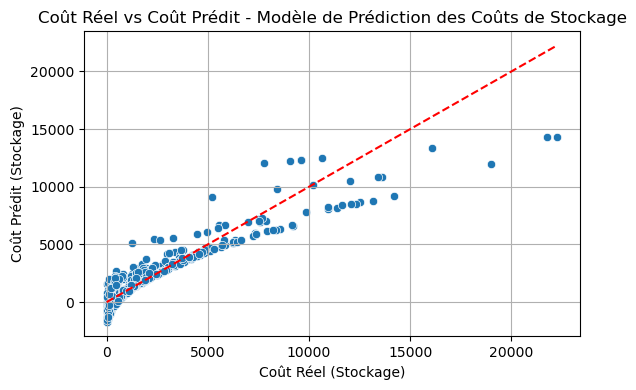

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

# Scatter plot entre le coût réel (y_test) et le coût prédit (y_test_pred)
sns.scatterplot(x=y_test, y=y_pred)

# Tracer la ligne idéale où les prédictions égales aux valeurs réelles
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')

# Titre et labels des axes
plt.xlabel("Coût Réel (Stockage)")
plt.ylabel("Coût Prédit (Stockage)")
plt.title("Coût Réel vs Coût Prédit - Modèle de Prédiction des Coûts de Stockage")

# Affichage de la grille et ajustement du layout
plt.grid(True)
plt.tight_layout()
plt.show()


### 🔹Comparison of Multiple Regression Models for Storage Cost Prediction

C:\Users\oumeyma\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


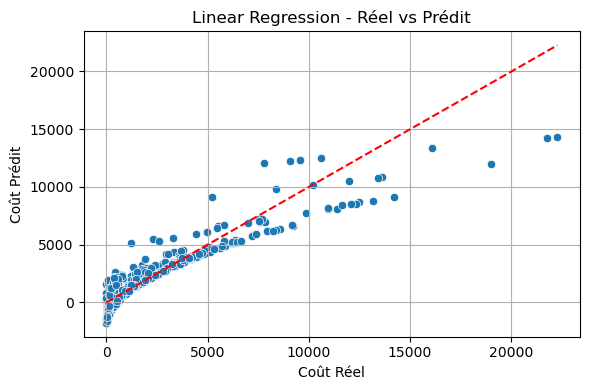

C:\Users\oumeyma\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


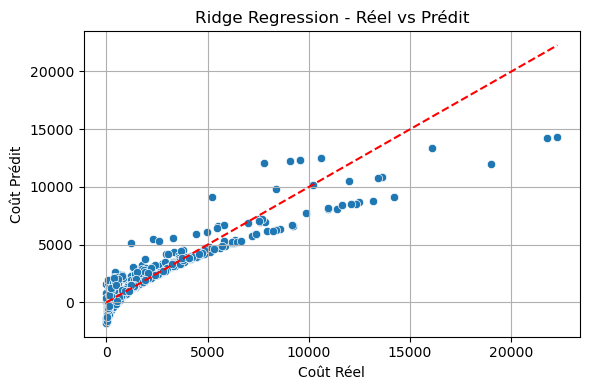

C:\Users\oumeyma\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


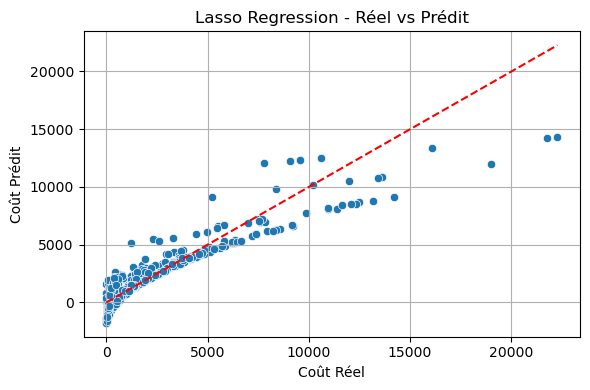

C:\Users\oumeyma\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


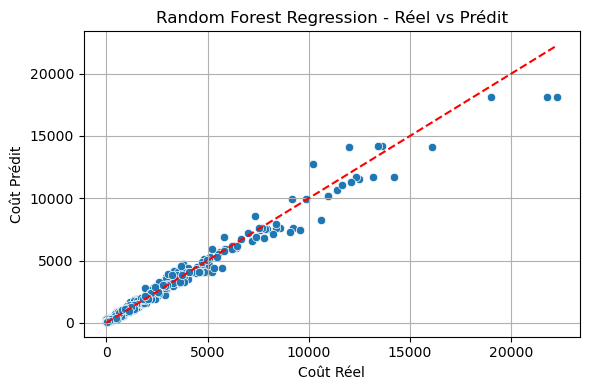

                     Modèle         MAE         RMSE        R²
3  Random Forest Regression  242.898307   458.804182  0.975416
2          Lasso Regression  710.759422  1139.023964  0.848480
0         Linear Regression  710.759526  1139.023977  0.848480
1          Ridge Regression  710.759525  1139.023978  0.848480


In [18]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Split des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Dictionnaire des modèles à tester
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=0.01),
    "Lasso Regression": Lasso(alpha=0.01),
    "Random Forest Regression": RandomForestRegressor(
        n_estimators=100, max_depth=5, min_samples_split=15,
        min_samples_leaf=10, random_state=42)
}

# Stocker les résultats
results = []

# Boucle sur chaque modèle
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Modèle": name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })

    # Afficher un scatterplot pour chaque modèle
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=y_test, y=y_pred)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel("Coût Réel")
    plt.ylabel("Coût Prédit")
    plt.title(f"{name} - Réel vs Prédit")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Convertir les résultats en DataFrame pour affichage clair
results_df = pd.DataFrame(results)
print(results_df.sort_values(by="R²", ascending=False))


##### ✅ Chaque point du graphique représente une observation de ton jeu de test :  

##### L'axe x = le coût réel du stockage (y_test)  

##### L'axe y = le coût prédit par ton modèle (y_pred)  

##### La ligne rouge en pointillés (r--) est la ligne idéale où la prédiction est exactement égale à la réalité (c’est la ligne y = x).  

##### ✅Random Forest Regression : Meilleur modèle, faible erreur, R² de 0.98.

##### ✅Lasso, Linear, et Ridge Regression : Moins performants, R² de 0.85.

C:\Users\oumeyma\AppData\Local\Temp\ipykernel_1260\2059627425.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Modèle", y="R²", data=df_results, palette="viridis")


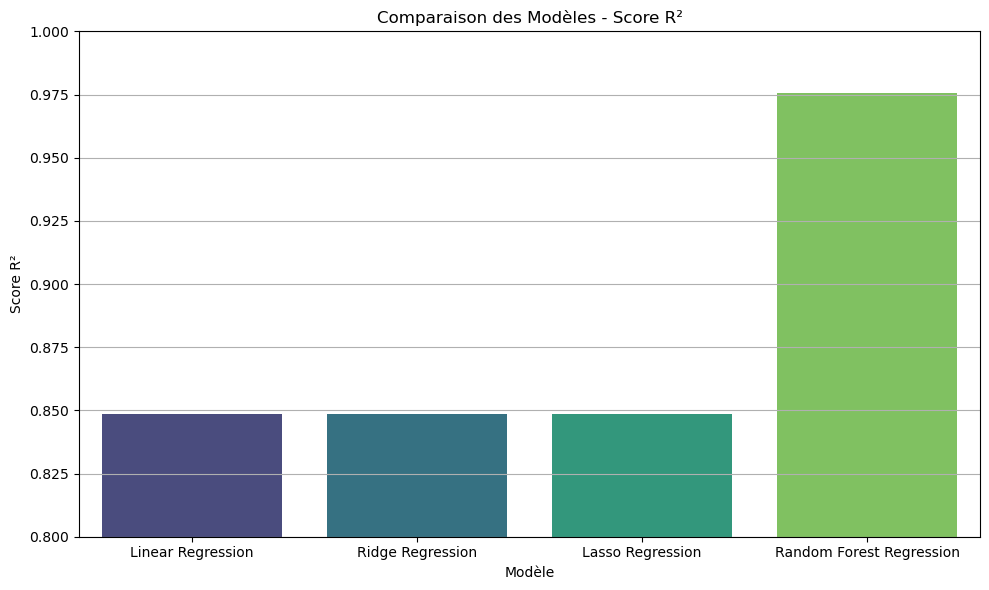

In [19]:
df_results = pd.DataFrame(results)

plt.figure(figsize=(10, 6))
sns.barplot(x="Modèle", y="R²", data=df_results, palette="viridis")
plt.title("Comparaison des Modèles - Score R²")
plt.ylabel("Score R²")
plt.ylim(0.8, 1)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


In [21]:
import joblib

# Entraînement (tu l’as déjà)
best_model = models["Random Forest Regression"]
best_model.fit(X_train, y_train)

# Sauvegarde
joblib.dump(best_model, 'random_forest_model.pkl')


['random_forest_model.pkl']

In [39]:
from flask import Flask, request, jsonify
import joblib
import numpy as np

# Initialiser l'app Flask
app = Flask(__name__)

# Charger le modèle
model = joblib.load('random_forest_model.pkl')

@app.route('/')
def home():
    return "📈 API - Prédiction de la demande (Random Forest Regression)"

@app.route('/predict', methods=['POST'])
def predict():
    data = request.get_json()

    # Assure-toi que le JSON contient une liste de features
    features = data.get('features')
    if features is None:
        return jsonify({"error": "Aucune donnée fournie"}), 400

    # Convertir en tableau numpy
    input_data = np.array(features).reshape(1, -1)

    # Prédiction
    prediction = model.predict(input_data)

    return jsonify({
        "prediction": float(prediction[0])
    })

if __name__ == '__main__':
    app.run(debug=True)


 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
 * Restarting with watchdog (windowsapi)


SystemExit: 1

C:\Users\oumeyma\AppData\Roaming\Python\Python312\site-packages\IPython\core\interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [41]:
pip install flask joblib numpy


Note: you may need to restart the kernel to use updated packages.
